# Exp 4 : Implement Logistic Regression using machine learning method without using sklearn.

**Import & Load Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load customer dataset
print("Loading customer dataset...")
df = pd.read_csv("customer.csv")

print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {list(df.columns)}")
print(f"\nTarget distribution:")
print(df['Purchased'].value_counts())
print(f"\nTarget distribution (%):")
print(df['Purchased'].value_counts(normalize=True) * 100)

print(f"\nFirst few rows:")
df.head()

Loading customer dataset...
Dataset shape: (18, 6)
Dataset columns: ['Age', 'Income', 'Gender_Male', 'City_Delhi', 'City_Mumbai', 'Purchased']

Target distribution:
Purchased
1    9
0    9
Name: count, dtype: int64

Target distribution (%):
Purchased
1    50.0
0    50.0
Name: proportion, dtype: float64

First few rows:


,Age,Income,Gender_Male,City_Delhi,City_Mumbai,Purchased
0,-2.078147,-3.870288,1.253566,1.414214,-0.797724,1
1,0.571681,-0.692186,-0.797724,1.414214,-0.797724,1
2,0.479554,0.395851,1.253566,-0.707107,1.253566,1
3,1.637140,0.788091,1.253566,1.414214,-0.797724,1
4,-0.770161,0.131660,-0.797724,-0.707107,-0.797724,1


**Select Target & Two Best Features**

In [2]:
# Identify target column
target_col = 'Purchased'
print("Target column:", target_col)

# Get feature columns (excluding target)
feature_cols = [col for col in df.columns if col != target_col]
print("Available features:", feature_cols)

# Select top-2 correlated features with target for 2D visualization
corr = df.corr()[target_col].abs().sort_values(ascending=False)
top2 = corr.index[1:3].tolist()   # skip target itself
print("\nSelected features for 2D decision boundary:", top2)
print("Correlation with target:")
for feat in top2:
    print(f"  {feat}: {corr[feat]:.3f}")

# For training, we'll use all features
X_all = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

# For visualization, use only top 2 features
X_viz = df[top2].values

# Add intercept (bias term) for both
X_all_b = np.c_[np.ones((X_all.shape[0], 1)), X_all]
X_viz_b = np.c_[np.ones((X_viz.shape[0], 1)), X_viz]

print(f"\nAll features shape: {X_all.shape}")
print(f"All features with bias shape: {X_all_b.shape}")
print(f"Viz features shape: {X_viz.shape}")
print(f"Target shape: {y.shape}")
print(f"Target values: {np.unique(y)}")

# Display basic statistics
print(f"\nDataset statistics:")
print(f"Total samples: {len(y)}")
print(f"Class 0 (Not Purchased): {np.sum(y == 0)} ({np.mean(y == 0)*100:.1f}%)")
print(f"Class 1 (Purchased): {np.sum(y == 1)} ({np.mean(y == 1)*100:.1f}%)")

Target column: Purchased
Available features: ['Age', 'Income', 'Gender_Male', 'City_Delhi', 'City_Mumbai']

Selected features for 2D decision boundary: ['Gender_Male', 'City_Delhi']
Correlation with target:
  Gender_Male: 0.570
  City_Delhi: 0.471

All features shape: (18, 5)
All features with bias shape: (18, 6)
Viz features shape: (18, 2)
Target shape: (18, 1)
Target values: [0 1]

Dataset statistics:
Total samples: 18
Class 0 (Not Purchased): 9 (50.0%)
Class 1 (Purchased): 9 (50.0%)


**Logistic Regression Functions**

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_cost(X, y, theta):
    m = len(y)
    preds = sigmoid(X.dot(theta))
    epsilon = 1e-15
    preds = np.clip(preds, epsilon, 1 - epsilon)
    return -(1/m) * np.sum(y*np.log(preds) + (1-y)*np.log(1-preds))

def compute_gradient(X, y, theta):
    m = len(y)
    preds = sigmoid(X.dot(theta))
    return (1/m) * X.T.dot(preds - y)

def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []
    for i in range(iterations):
        grad = compute_gradient(X, y, theta)
        theta -= alpha * grad
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")
    return theta, cost_history

def predict(X, theta):
    return (sigmoid(X.dot(theta)) >= 0.5).astype(int)


**Train Model**

In [4]:
# Split data into train and test sets (80-20 split)
np.random.seed(42)
n_samples = len(y)
indices = np.random.permutation(n_samples)
train_size = int(0.8 * n_samples)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_all_b[train_idx]
X_test = X_all_b[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Features used: {len(feature_cols)}")

# Initialize parameters
theta_init = np.random.normal(0, 0.01, (X_train.shape[1], 1))

# Hyperparameters
alpha = 0.1  # learning rate
iterations = 1000

print(f"\nStarting gradient descent...")
print(f"Learning rate: {alpha}")
print(f"Iterations: {iterations}")
print(f"Initial parameters shape: {theta_init.shape}")

# Train the model
theta_final, cost_history = gradient_descent(X_train, y_train, theta_init, alpha, iterations)

print(f"\nTraining completed!")
print(f"Final parameters: {theta_final.ravel()}")
print(f"Final cost: {cost_history[-1]:.4f}")

# Evaluate on training set
y_train_pred = predict(X_train, theta_final)
train_accuracy = np.mean(y_train_pred == y_train) * 100

# Evaluate on test set
y_test_pred = predict(X_test, theta_final)
test_accuracy = np.mean(y_test_pred == y_test) * 100

print(f"\nModel Performance:")
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Calculate additional metrics for test set
from sklearn.metrics import classification_report, confusion_matrix
print(f"\nDetailed Test Set Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Not Purchased', 'Purchased']))

Training set size: 14
Test set size: 4
Features used: 5

Starting gradient descent...
Learning rate: 0.1
Iterations: 1000
Initial parameters shape: (6, 1)
Iteration 0, Cost: 0.6719
Iteration 100, Cost: 0.3468
Iteration 200, Cost: 0.3179
Iteration 300, Cost: 0.3014
Iteration 400, Cost: 0.2897
Iteration 500, Cost: 0.2807
Iteration 600, Cost: 0.2734
Iteration 700, Cost: 0.2674
Iteration 800, Cost: 0.2623
Iteration 900, Cost: 0.2578

Training completed!
Final parameters: [ 1.10945242  1.22521351 -1.99456516  2.62600966  0.03649329 -1.35706544]
Final cost: 0.2540

Model Performance:
Training Accuracy: 92.86%
Test Accuracy: 75.00%

Detailed Test Set Results:
Confusion Matrix:
[[1 1]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

Not Purchased       1.00      0.50      0.67         2
    Purchased       0.67      1.00      0.80         2

     accuracy                           0.75         4
    macro avg       0.83      0.75      0.73         4
 weig

**Plot Cost Convergence**

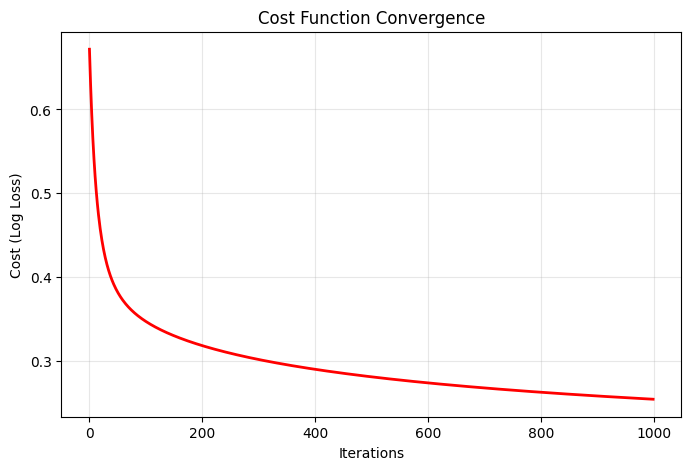

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(iterations), cost_history, 'r-', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Cost (Log Loss)")
plt.title("Cost Function Convergence")
plt.grid(True, alpha=0.3)
plt.show()


**Plot Decision Boundary**

Training simplified model with top 2 features for visualization...
Iteration 0, Cost: 0.6814
Iteration 100, Cost: 0.4171
Iteration 200, Cost: 0.4044
Iteration 300, Cost: 0.4025
Iteration 400, Cost: 0.4021


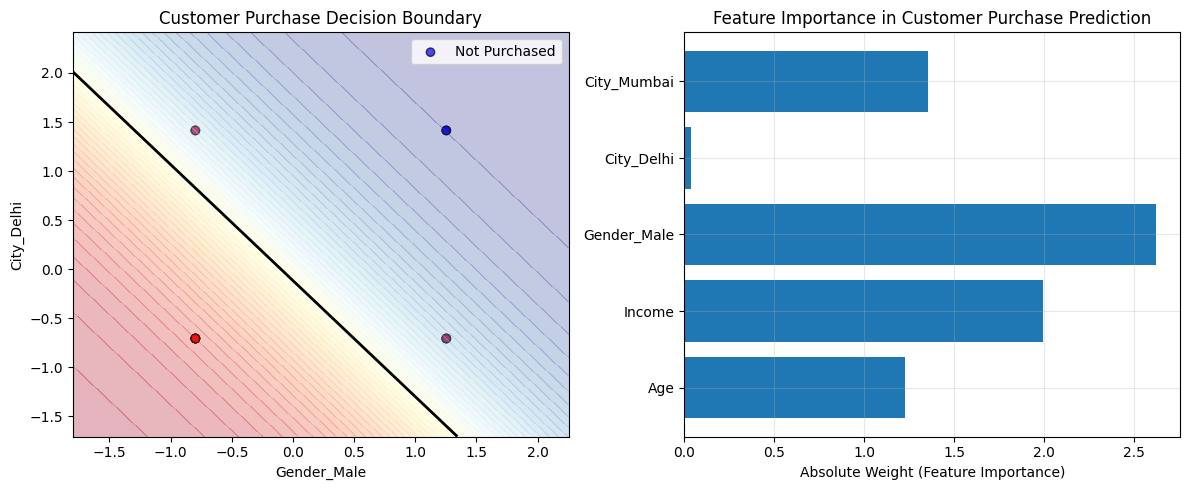

Feature Importance Ranking:
Gender_Male: 2.626
Income: 1.995
City_Mumbai: 1.357
Age: 1.225
City_Delhi: 0.036


In [6]:
# Train a separate model with only top 2 features for visualization
print("Training simplified model with top 2 features for visualization...")
theta_viz = np.random.normal(0, 0.01, (X_viz_b.shape[1], 1))
theta_viz_final, _ = gradient_descent(X_viz_b, y, theta_viz, alpha, 500)

plt.figure(figsize=(12, 5))

# Plot 1: Decision Boundary with top 2 features
plt.subplot(1, 2, 1)
# Scatter points
colors = ['red' if label == 0 else 'blue' for label in y.ravel()]
plt.scatter(X_viz[:,0], X_viz[:,1], c=colors, alpha=0.7, edgecolors="k")

# Create grid for decision boundary
x_min, x_max = X_viz[:,0].min()-1, X_viz[:,0].max()+1
y_min, y_max = X_viz[:,1].min()-1, X_viz[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[np.ones((xx.ravel().shape[0], 1)), xx.ravel(), yy.ravel()]
probs = sigmoid(grid.dot(theta_viz_final)).reshape(xx.shape)

# Contour for boundary at 0.5
plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
plt.contourf(xx, yy, probs, levels=50, alpha=0.3, cmap='RdYlBu')

plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.title("Customer Purchase Decision Boundary")
plt.legend(['Not Purchased', 'Purchased'], loc='upper right')

# Plot 2: Feature importance
plt.subplot(1, 2, 2)
feature_importance = np.abs(theta_final[1:].ravel())  # exclude bias term
feature_names_plot = feature_cols

plt.barh(range(len(feature_importance)), feature_importance)
plt.yticks(range(len(feature_importance)), feature_names_plot)
plt.xlabel('Absolute Weight (Feature Importance)')
plt.title('Feature Importance in Customer Purchase Prediction')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print feature importance ranking
print("Feature Importance Ranking:")
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

for i, row in importance_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.3f}")

In [7]:
# Additional Analysis: Probability predictions and insights

def predict_proba(X, theta):
    """Return prediction probabilities"""
    return sigmoid(X.dot(theta))

# Get prediction probabilities for test set
test_probabilities = predict_proba(X_test, theta_final)

# Show some example predictions
print("Sample Predictions on Test Set:")
print("="*50)
for i in range(min(10, len(X_test))):
    actual = y_test[i][0]
    prob = test_probabilities[i][0]
    predicted = 1 if prob >= 0.5 else 0
    confidence = max(prob, 1-prob) * 100
    
    print(f"Customer {i+1}:")
    print(f"  Actual: {'Purchased' if actual == 1 else 'Not Purchased'}")
    print(f"  Predicted: {'Purchased' if predicted == 1 else 'Not Purchased'}")
    print(f"  Probability of Purchase: {prob:.3f}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"  Correct: {'✓' if predicted == actual else '✗'}")
    print()

# Summary of the Logistic Regression Implementation
print("\n" + "="*60)
print("LOGISTIC REGRESSION IMPLEMENTATION SUMMARY")
print("="*60)
print(f"✓ Dataset: Customer Purchase Prediction")
print(f"✓ Total Samples: {len(y)}")
print(f"✓ Features Used: {len(feature_cols)} ({', '.join(feature_cols)})")
print(f"✓ Algorithm: Gradient Descent (from scratch)")
print(f"✓ Final Training Accuracy: {train_accuracy:.2f}%")
print(f"✓ Final Test Accuracy: {test_accuracy:.2f}%")
print(f"✓ Model Converged: {'Yes' if cost_history[-1] < cost_history[0] else 'No'}")
print(f"✓ Most Important Feature: {importance_df.iloc[0]['Feature']}")

print(f"\nKey Components Implemented:")
print(f"1. Sigmoid Function: σ(z) = 1/(1 + e^(-z))")
print(f"2. Cost Function: J(θ) = -(1/m)Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]")
print(f"3. Gradient Descent: θ = θ - α*(1/m)*X^T*(ŷ-y)")
print(f"4. Prediction: ŷ = 1 if σ(X*θ) ≥ 0.5 else 0")
print("="*60)

Sample Predictions on Test Set:
Customer 1:
  Actual: Purchased
  Predicted: Purchased
  Probability of Purchase: 0.896
  Confidence: 89.6%
  Correct: ✓

Customer 2:
  Actual: Not Purchased
  Predicted: Purchased
  Probability of Purchase: 0.950
  Confidence: 95.0%
  Correct: ✗

Customer 3:
  Actual: Not Purchased
  Predicted: Not Purchased
  Probability of Purchase: 0.090
  Confidence: 91.0%
  Correct: ✓

Customer 4:
  Actual: Purchased
  Predicted: Purchased
  Probability of Purchase: 0.996
  Confidence: 99.6%
  Correct: ✓


LOGISTIC REGRESSION IMPLEMENTATION SUMMARY
✓ Dataset: Customer Purchase Prediction
✓ Total Samples: 18
✓ Features Used: 5 (Age, Income, Gender_Male, City_Delhi, City_Mumbai)
✓ Algorithm: Gradient Descent (from scratch)
✓ Final Training Accuracy: 92.86%
✓ Final Test Accuracy: 75.00%
✓ Model Converged: Yes
✓ Most Important Feature: Gender_Male

Key Components Implemented:
1. Sigmoid Function: σ(z) = 1/(1 + e^(-z))
2. Cost Function: J(θ) = -(1/m)Σ[y*log(ŷ) + (1-y)*l